# PCMCI+ and LD3 with synthetic data

Jacqueline Maasch | March 2026

## Preamble

In [1]:
# General imports.
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import time

# Time series causal discovery.
import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI # also for PCMCI+
from tigramite.independence_tests.gsquared import Gsquared # univariate discrete/categorical vars
from tigramite.independence_tests.cmisymb import CMIsymb # multivariate discrete/categorical vars (permutation-based)

# Vanilla causal discovery.
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.utils.cit import CIT

# Local discovery.
from ld3 import LD3

# Metrics.
from dodiscover.metrics import structure_hamming_dist as SHD

# Graphical modeling.
import networkx as nx

/Users/jmaasch/anaconda3/envs/icp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define functions

In [2]:
u = lambda params : np.random.randint(low=params[0],high=params[1],size=params[2])
def get_data(n: int = 1000, 
             low: int = 0, 
             high: int = 4):

    # Time 0.
    a0 = u([low,high,n])
    y0 = u([low,high,n])
    x0 = y0 + u([low,high,n])
    r0 = x0 - u([low,high,n])

    # Time 1.
    a1 = u([low,high,n])
    y1 = y0 + u([low,high,n])
    x1 = a0 + y0 + x0 - u([low,high,n])
    r1 = a0 + x1 - u([low,high,n])
    
    # Time 2.
    a2 = u([low,high,n])
    y2 = y1 + u([low,high,n])
    x2 = (a1 + y1 + x1 - y2 - u([low,high,n])) // 4
    r2 = a1 + x2 - u([low,high,n])
    
    # Time 3.
    a3 = u([low,high,n])
    y3 = y2 - u([low,high,n])
    x3 = (a2 + y2 + x2 - y3 - u([low,high,n])) // 4
    r3 = a2 + x3 - u([low,high,n])
    
    # Time 4.
    a4 = u([low,high,n])
    y4 = (y1 + y3 - u([low,high,n])) // 2
    x4 = (a3 + x3 + y4 - u([low,high,n])) // 4
    r4 = a3 + x4 - u([low,high,n])

    # Init dataframe.
    df = pd.DataFrame({"Y0": y0, "X0": x0, "R0": r0, "A0": a0,
                       "Y1": y1, "X1": x1, "R1": r1, "A1": a1, 
                       "Y2": y2, "X2": x2, "R2": r2, "A2": a2,
                       "Y3": y3, "X3": x3, "R3": r3, "A3": a3,
                       "Y4": y4, "X4": x4, "R4": r4, "A4": a4}).astype(int)
    #df = abs(df)

    # Generate graph.
    dol = {"y0": ["x0", "x1", "y1"],
           "x0": ["r0", "x1"], 
           "r0": [],
           "a0": ["x1", "r1"],
           "y1": ["y2", "x2", "y4"], 
           "x1": ["r1", "x2"], 
           "r1": [],
           "a1": ["x2", "r2"],
           "y2": ["y3", "x2", "x3"], 
           "x2": ["r2", "x3"], 
           "r2": [], 
           "a2": ["x3", "r3"],
           "y3": ["y4", "x3"], 
           "x3": ["r3", "x4"], 
           "r3": [],
           "a3": ["x2", "r2"],
           "y4": ["x4"], 
           "x4": ["r4"], 
           "r4": [], 
           "a4": []}
    G = nx.from_dict_of_lists(dol, create_using = nx.DiGraph)
    
    return df,G

In [3]:
def plot_nx(adjacency_matrix,
            labels,
            figsize = (5,5),
            dpi = 75,
            node_size = 800,
            arrow_size = 10):
    g = nx.from_numpy_array(adjacency_matrix, create_using = nx.DiGraph)
    plt.figure(figsize = figsize, dpi = dpi)  
    nx.draw_circular(g, 
                     node_size = node_size, 
                     node_color = "pink",
                     labels = dict(zip(list(range(len(labels))), labels)), 
                     arrowsize = arrow_size,
                     with_labels = True)
    plt.show()
    plt.close()

In [4]:
def run_ld3(df,
            test: str = "chi",
            exposure: str = "X",
            outcome: str = "Y",
            alpha: float = 0.01):

    ld3 = LD3(data = df, 
              independence_test = test)
    start = time.time()
    sdc,acde = ld3.get_sdc_cde_adjustment(exposure = exposure, 
                                          outcome = outcome,
                                          alpha = alpha)
    print("\nResults complete in {}s.".format(round(time.time() - start, 4)))
    print("Total independence tests performed:", ld3.total_tests)
    print("Predicted parents of outcome =", sorted(acde))

## Generate data

In [5]:
n = int(10e3)
df,G = get_data(n = n)
display(df)

,Y0,X0,R0,A0,Y1,X1,R1,A1,Y2,X2,R2,A2,Y3,X3,R3,A3,Y4,X4,R4,A4
0,1,1,1,1,3,1,2,0,4,-1,-1,0,2,-1,-1,1,2,-1,0,0
1,0,3,3,2,3,5,7,3,5,0,2,1,3,0,0,0,3,0,-1,0
2,3,5,3,0,6,6,4,2,9,1,0,3,8,0,3,3,6,1,2,1
3,1,2,0,1,1,1,1,0,2,-1,-1,2,-1,1,3,1,-2,-1,0,2
4,0,2,2,3,3,2,5,3,4,0,0,3,4,0,2,2,3,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,3,1,1,2,5,6,1,2,1,1,2,1,0,0,0,0,-1,-3,1
9996,1,3,2,2,3,4,5,3,3,1,4,2,0,1,0,0,1,-1,-4,3
9997,1,2,0,3,4,5,6,1,7,0,0,0,7,-1,-3,3,4,0,2,1
9998,1,1,-2,1,3,1,2,3,5,0,2,2,2,1,2,0,1,0,0,3


array([[<Axes: title={'center': 'Y0'}>, <Axes: title={'center': 'X0'}>,
        <Axes: title={'center': 'R0'}>, <Axes: title={'center': 'A0'}>],
       [<Axes: title={'center': 'Y1'}>, <Axes: title={'center': 'X1'}>,
        <Axes: title={'center': 'R1'}>, <Axes: title={'center': 'A1'}>],
       [<Axes: title={'center': 'Y2'}>, <Axes: title={'center': 'X2'}>,
        <Axes: title={'center': 'R2'}>, <Axes: title={'center': 'A2'}>],
       [<Axes: title={'center': 'Y3'}>, <Axes: title={'center': 'X3'}>,
        <Axes: title={'center': 'R3'}>, <Axes: title={'center': 'A3'}>],
       [<Axes: title={'center': 'Y4'}>, <Axes: title={'center': 'X4'}>,
        <Axes: title={'center': 'R4'}>, <Axes: title={'center': 'A4'}>]],
      dtype=object)

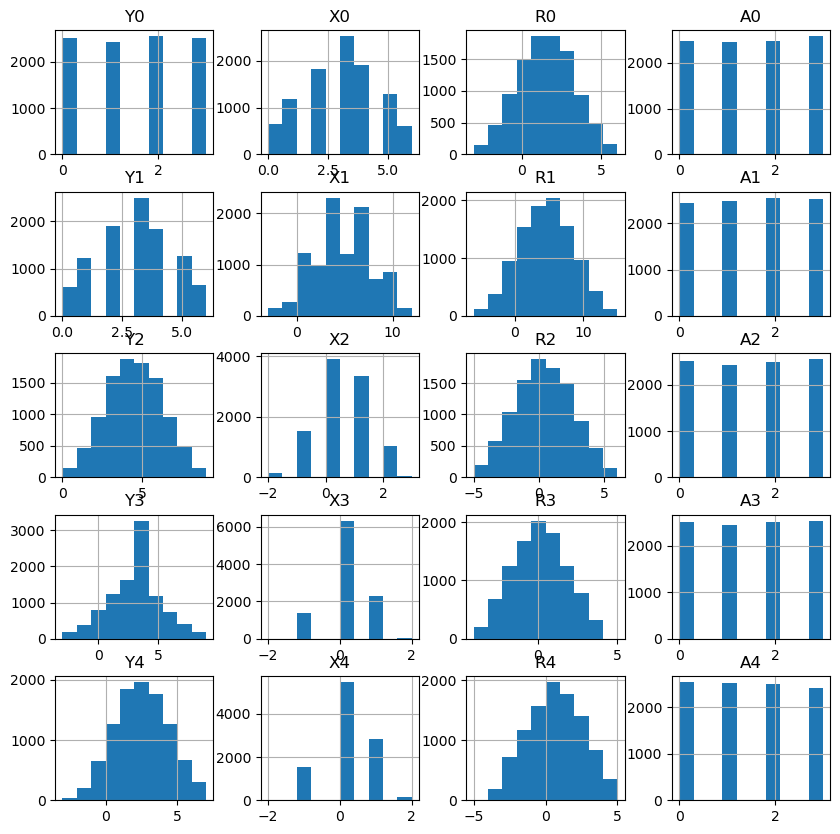

In [6]:
df.hist(figsize = (10,10))

In [7]:
adj = nx.to_numpy_array(G)
adj = adj.astype(int)
adj

array([[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

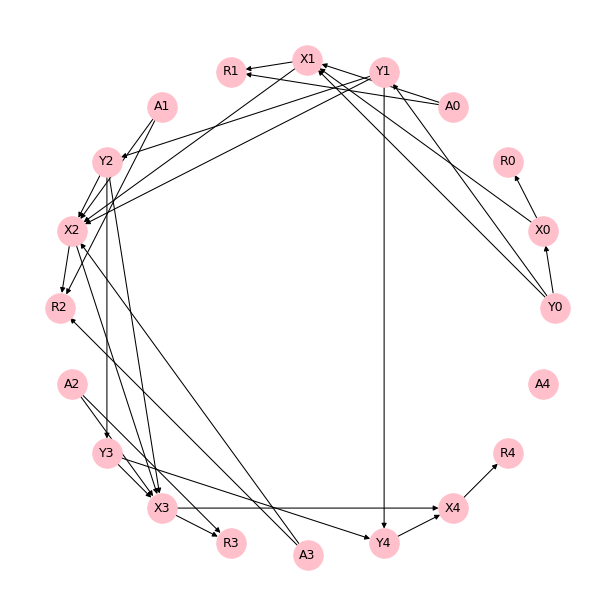

In [8]:
plot_nx(adj, labels = df.columns, figsize = (8,8))

## Vanilla PC

Depth=4, working on node 19: 100%|███████████| 20/20 [00:00<00:00, 770.41it/s]



Results complete in 0.473s.


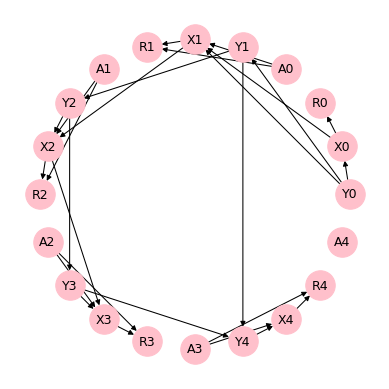

Total disparate elements = 7


In [9]:
# G-Square independence test.
# https://causal-learn.readthedocs.io/en/latest/independence_tests_index/gsq.html
alpha = 0.01
start = time.time()
g_pred = pc(df.to_numpy(), indep_test = "gsq", alpha = alpha)
print("\nResults complete in {}s.".format(round(time.time() - start, 4)))

# Visualization using pydot.
#g_pred.draw_pydot_graph()

# Save the graph.
pyd = GraphUtils.to_pydot(g_pred.G, labels = list(df.columns))
#pyd.write_png(f"pc_venture.png")

# Convert to networkx.
a_pred = g_pred.G.graph.copy()
a_pred = np.triu(a_pred)
a_pred[a_pred == -1] = 1
g_pred_nx = nx.from_numpy_array(a_pred, create_using = nx.DiGraph)

# Plot.
plot_nx(a_pred,
        labels = list(df.columns),
        figsize = (5,5),
        dpi = 75,
        node_size = 800,
        arrow_size = 10)

# Score (structural hamming distance).
# Appears buggy.
#shd = SHD(G, g_pred_nx, double_for_anticausal = False)
#print(f"Structural Hamming Distance = {shd}")
wrong = np.sum(np.where(adj != a_pred, 1, 0))
print(f"Total disparate elements = {wrong}")

In [10]:
g_pred_nx

In [11]:
G

Depth=4, working on node 19: 100%|███████████| 20/20 [00:00<00:00, 962.79it/s]



Results complete in 0.4814s.


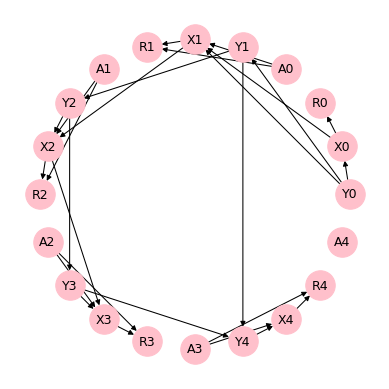

Total disparate elements = 7


In [12]:
# Chi-square independence test.
alpha = 0.01
start = time.time()
g_pred = pc(df.to_numpy(), indep_test = "chisq", alpha = alpha)
print("\nResults complete in {}s.".format(round(time.time() - start, 4)))

# Visualization using pydot.
#g_pred.draw_pydot_graph()

# Save the graph.
pyd = GraphUtils.to_pydot(g_pred.G, labels = list(df.columns))
#pyd.write_png(f"pc_venture.png")

# Convert to networkx.
a_pred = g_pred.G.graph.copy()
a_pred = np.triu(a_pred)
a_pred[a_pred == -1] = 1
g_pred_nx = nx.from_numpy_array(a_pred, create_using = nx.DiGraph)

# Plot.
plot_nx(a_pred,
        labels = list(df.columns),
        figsize = (5,5),
        dpi = 75,
        node_size = 800,
        arrow_size = 10)

# Score (structural hamming distance).
# Appears buggy.
#shd = SHD(G, g_pred_nx, double_for_anticausal = False)
#print(f"Structural Hamming Distance = {shd}")
wrong = np.sum(np.where(adj != a_pred, 1, 0))
print(f"Total disparate elements = {wrong}")

## LD3

In [13]:
pairs = [("X0","R0"), ("X1","R1"), ("X2","R2"), ("X3","R3"), ("X4","R4")]
test = "gsq" #"chi"
alpha = 0.01
for pair in pairs:
    print(pair)
    run_ld3(df,
            test = test,
            exposure = pair[0],
            outcome = pair[1],
            alpha = alpha)
    print("\n-----------------------------\n")

('X0', 'R0')

Results complete in 0.007s.
Total independence tests performed: 50
Predicted parents of outcome = []

-----------------------------

('X1', 'R1')

Results complete in 0.3696s.
Total independence tests performed: 71
Predicted parents of outcome = ['A0', 'R0', 'R4', 'X0', 'X4', 'Y0', 'Y1', 'Y2', 'Y3', 'Y4']

-----------------------------

('X2', 'R2')

Results complete in 0.1476s.
Total independence tests performed: 68
Predicted parents of outcome = ['A0', 'A1', 'R0', 'R1', 'X0', 'X1', 'Y0', 'Y1']

-----------------------------

('X3', 'R3')

Results complete in 0.228s.
Total independence tests performed: 79
Predicted parents of outcome = []

-----------------------------

('X4', 'R4')

Results complete in 0.2575s.
Total independence tests performed: 78
Predicted parents of outcome = ['Y3']

-----------------------------



In [14]:
pairs = [("A0","R1"), ("A1","R2"), ("A2","R3"), ("A3","R4")]
test = "gsq" #"chi"
alpha = 0.01
for pair in pairs:
    print(pair)
    run_ld3(df,
            test = test,
            exposure = pair[0],
            outcome = pair[1],
            alpha = alpha)
    print("\n-----------------------------\n")

('A0', 'R1')

Results complete in 0.4857s.
Total independence tests performed: 79
Predicted parents of outcome = ['R0', 'R4', 'X0', 'X4', 'Y0', 'Y1', 'Y2', 'Y3', 'Y4']

-----------------------------

('A1', 'R2')

Results complete in 0.2548s.
Total independence tests performed: 78
Predicted parents of outcome = ['A0', 'R0', 'R1', 'X0', 'X1', 'X4', 'Y0', 'Y1', 'Y2', 'Y4']

-----------------------------

('A2', 'R3')

Results complete in 0.2123s.
Total independence tests performed: 73
Predicted parents of outcome = ['R0', 'R1', 'R2', 'X0', 'X1', 'X2', 'Y0', 'Y1', 'Y3']

-----------------------------

('A3', 'R4')

Results complete in 0.2548s.
Total independence tests performed: 79
Predicted parents of outcome = ['A2', 'R0', 'R1', 'Y3']

-----------------------------



In [17]:
# Only one time step.
test = "gsq" #"chi"
alpha = 0.01
run_ld3(df[["A0", "Y1", "X1", "R1"]],
        test = test,
        exposure = "A0",
        outcome = "R1",
        alpha = alpha)


Results complete in 0.003s.
Total independence tests performed: 11
Predicted parents of outcome = ['X1']


In [18]:
# Only one time step.
test = "gsq" #"chi"
alpha = 0.01
run_ld3(df[["A0", "Y1", "X1", "R1"]],
        test = test,
        exposure = "X1",
        outcome = "R1",
        alpha = alpha)


Results complete in 0.0057s.
Total independence tests performed: 11
Predicted parents of outcome = ['A0']


In [20]:
# Only one time step.
test = "gsq" #"chi"
alpha = 0.01
run_ld3(df[["A0", "Y0", "X2", "Y2", "Y1", "X1", "R1"]],
        test = test,
        exposure = "X1",
        outcome = "R1",
        alpha = alpha)


Results complete in 0.0173s.
Total independence tests performed: 24
Predicted parents of outcome = ['A0', 'Y0', 'Y1', 'Y2']


In [15]:
pairs = [("Y0","R0"), ("Y1","R1"), ("Y2","R2"), ("Y3","R3"), ("Y4","R4")]
test = "gsq" #"chi"
alpha = 0.01
for pair in pairs:
    print(pair)
    run_ld3(df,
            test = test,
            exposure = pair[0],
            outcome = pair[1],
            alpha = alpha)
    print("\n-----------------------------\n")

('Y0', 'R0')

Results complete in 0.0646s.
Total independence tests performed: 62
Predicted parents of outcome = ['R1', 'R2', 'X0', 'X1', 'X2', 'X3']

-----------------------------

('Y1', 'R1')

Results complete in 0.4191s.
Total independence tests performed: 70
Predicted parents of outcome = ['A0', 'R0', 'R2', 'X0', 'X1', 'X2', 'X3', 'Y0']

-----------------------------

('Y2', 'R2')

Results complete in 0.2319s.
Total independence tests performed: 78
Predicted parents of outcome = ['A1', 'R0']

-----------------------------

('Y3', 'R3')

Results complete in 0.1618s.
Total independence tests performed: 74
Predicted parents of outcome = ['A2', 'R4', 'X0', 'X1', 'X2', 'X3', 'X4', 'Y0', 'Y1']

-----------------------------

('Y4', 'R4')

Results complete in 0.0336s.
Total independence tests performed: 63
Predicted parents of outcome = ['A3', 'X0', 'X3', 'X4', 'Y1']

-----------------------------



## PCMCI+

In [16]:
# Config.
TAU_MAX = 4
ALPHA = 0.01

In [17]:
# Format data.
t0 = df[["Y0", "X0", "R0", "A0"]].to_numpy()
t1 = df[["Y1", "X1", "R1", "A1"]].to_numpy()
t2 = df[["Y2", "X2", "R2", "A2"]].to_numpy()
t3 = df[["Y3", "X3", "R3", "A3"]].to_numpy()
t4 = df[["Y4", "X4", "R4", "A4"]].to_numpy()
t_arrays = np.array([t0, t1, t2, t3, t4])

In [18]:
# Cast as tigramite dataframe.
df_tg = pp.DataFrame(t_arrays, 
                     var_names = ["Y", "X", "R", "A"],
                     analysis_mode = "multiple")
df_tg

In [19]:
# Sanity check.
print(df_tg.var_names)
print("Total episodes:", df_tg.M)
print("Time steps per trajectory:", df_tg.T[0])
print("Total variables per trajectory:", df_tg.N)

['Y', 'X', 'R', 'A']
Total episodes: 5
Time steps per trajectory: 10000
Total variables per trajectory: 4


In [20]:
#tp.plot_timeseries(df_tg, figsize=(20, 20)); plt.show()

In [21]:
# Init independence test and discovery algorithm.
gsq = Gsquared(significance = "analytic")
pcmci = PCMCI(dataframe = df_tg, 
              cond_ind_test = gsq,
              verbosity = 1)

In [ ]:
# Run PCMCI+.
pcmci.verbosity = 2
results = pcmci.run_pcmciplus(tau_min = 0, 
                              tau_max = TAU_MAX, 
                              pc_alpha = ALPHA)


##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = gsquared
tau_min = 1
tau_max = 4
pc_alpha = [0.01]
max_conds_dim = None
max_combinations = 1



## Variable Y

Iterating through pc_alpha = [0.01]:

# pc_alpha = 0.01 (1/1):

Testing condition sets of dimension 0:

    Link (Y -1) -?> Y (1/16):
    Subset 0: () gives pval = 0.00000 / val =  4424.868
    No conditions of dimension 0 left.

    Link (Y -2) -?> Y (2/16):
    Subset 0: () gives pval = 0.00000 / val =  4469.727
    No conditions of dimension 0 left.

    Link (Y -3) -?> Y (3/16):
    Subset 0: () gives pval = 0.00000 / val =  4315.625
    No conditions of dimension 0 left.

    Link (Y -4) -?> Y (4/16):
    Subset 0: () gives pval = 0.00000 / val =  4072.836
    No conditions of dimension 0 left.

    Link (X -1) -?> Y (5/16):
    Subset 0: () gives pval = 0.00000 / val =  5312.825
    No conditions of dimension 0 left.

    Link (X -2) -?> Y (6/16):
    Subset 0: () gives pval 

In [ ]:
print("Graph")
print (results['graph'])
print("Adjacency MCI partial correlations")
print (results['val_matrix'].round(2))
print("Adjacency p-values")
print (results['p_matrix'].round(3))

In [ ]:
# View process graph.
tp.plot_graph(val_matrix = results["val_matrix"],
              graph = results["graph"],
              var_names = ["Y", "X", "R", "A"],
              link_colorbar_label = "cross-MCI (edges)",
              node_colorbar_label = "auto-MCI (nodes)")
plt.show()

In [ ]:
# Plot time series graph.
tp.plot_time_series_graph(figsize = (8, 8),
                          node_size = 0.05,
                          val_matrix = results["val_matrix"],
                          graph = results["graph"],
                          var_names = ["Y", "X", "R", "A"],
                          link_colorbar_label = "MCI")
plt.show()

# End document